In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("adults.csv", skipinitialspace=True)

df.columns = [
    "age","workclass","fnlwgt","education","education-num",
    "marital-status","occupation","relationship","race","sex",
    "capital-gain","capital-loss","hours-per-week","native-country","income"
]

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [ ]:

#Displaying the first 5 rows of the dataset
print("\nOverall Statistics:\n")
print(df.describe())

In [17]:
# Replace ? with NaN
df.replace('?', np.nan, inplace=True)

# Fill categorical missing values
df['workclass'] = df['workclass'].fillna(df['workclass'].mode()[0])
df['occupation'] = df['occupation'].fillna(df['occupation'].mode()[0])

# Fill numeric missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [18]:
print("Overall Statistics:\n")
df.describe()

Overall Statistics:



,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32560.000000,3.256000e+04,32560.000000,32560.000000,32560.000000,32560.000000
mean,38.581634,1.897818e+05,10.080590,1077.615172,87.306511,40.437469
std,13.640642,1.055498e+05,2.572709,7385.402999,402.966116,12.347618
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178315e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783630e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370545e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


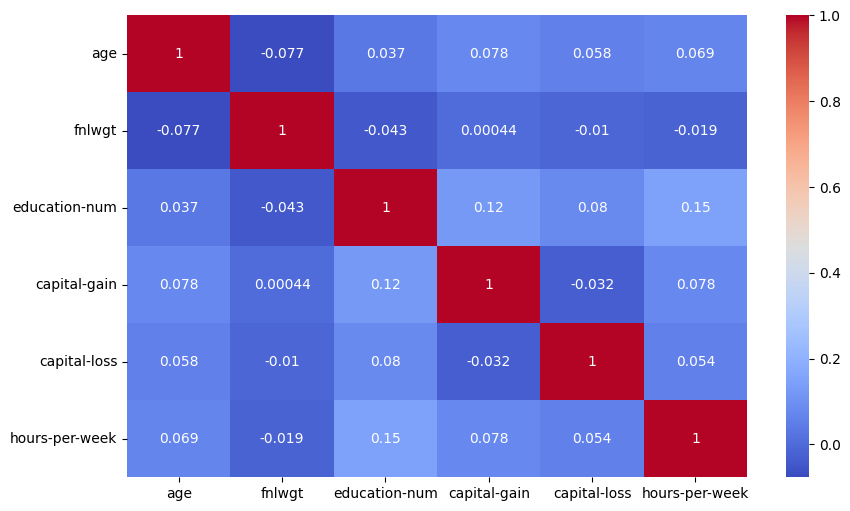

In [19]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [20]:
print("Mean age grouped by sex:\n")
df.groupby("sex")["age"].mean()

Mean age grouped by sex:



sex
Female    36.858230
Male      39.433567
Name: age, dtype: float64

In [21]:
print("Median age grouped by marital status:\n")
df.groupby("marital-status")["age"].median()

Median age grouped by marital status:



marital-status
Divorced                 42.0
Married-AF-spouse        30.0
Married-civ-spouse       42.0
Married-spouse-absent    40.0
Never-married            25.0
Separated                38.0
Widowed                  60.0
Name: age, dtype: float64

In [22]:
print("Standard deviation of age grouped by sex & marital status:\n")
df.groupby(["sex", "marital-status"])["age"].std()

Standard deviation of age grouped by sex & marital status:



sex     marital-status       
Female  Divorced                 10.591593
        Married-AF-spouse        13.966207
        Married-civ-spouse       11.335067
        Married-spouse-absent    12.552383
        Never-married            10.223440
        Separated                11.029510
        Widowed                  11.942721
Male    Divorced                 10.097769
        Married-AF-spouse         7.195678
        Married-civ-spouse       12.063821
        Married-spouse-absent    12.194621
        Never-married             9.830220
        Separated                10.520600
        Widowed                  13.886480
Name: age, dtype: float64

In [23]:
print("Mean age grouped by income:\n")
df.groupby("income")["age"].mean()

print("\nMean age grouped by income and sex:\n")
df.groupby(["income", "sex"])["age"].mean()

Mean age grouped by income:


Mean age grouped by income and sex:



income  sex   
<=50K   Female    36.210801
        Male      37.146890
>50K    Female    42.125530
        Male      44.625788
Name: age, dtype: float64

In [24]:
print("Count of marital status:\n")
df["marital-status"].value_counts()

Count of marital status:



marital-status
Married-civ-spouse       14976
Never-married            10682
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

In [25]:
print("Min age by sex:\n")
df.groupby("sex")["age"].min()

print("\nMax age by sex:\n")
df.groupby("sex")["age"].max()

Min age by sex:


Max age by sex:



sex
Female    90
Male      90
Name: age, dtype: int64

In [26]:
iris_df = pd.read_csv("iris.csv")

print("Dataset Preview:\n")
iris_df.head()

Dataset Preview:



,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [27]:
print("Unique Species:\n")
iris_df["Species"].unique()

Unique Species:



<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [28]:
grouped = iris_df.groupby("Species")

print("Summary statistics:\n")
grouped.describe()

Summary statistics:



Id                                                        \
                count   mean       std    min     25%    50%     75%    max   
Species                                                                       
Iris-setosa      50.0   25.5  14.57738    1.0   13.25   25.5   37.75   50.0   
Iris-versicolor  50.0   75.5  14.57738   51.0   63.25   75.5   87.75  100.0   
Iris-virginica   50.0  125.5  14.57738  101.0  113.25  125.5  137.75  150.0   

                SepalLengthCm         ... PetalLengthCm      PetalWidthCm  \
                        count   mean  ...           75%  max        count   
Species                               ...                                   
Iris-setosa              50.0  5.006  ...         1.575  1.9         50.0   
Iris-versicolor          50.0  5.936  ...         4.600  5.1         50.0   
Iris-virginica           50.0  6.588  ...         5.875  6.9         50.0   

                                                           
                  mean       std  min  25%  50%  75%  max  
Species                                                    
Iris-setosa      0.244  0.107210  0.1  0.2  0.2  0.3  0.6  
Iris-versicolor  1.326  0.197753  1.0  1.2  1.3  1.5  1.8  
Iris-virginica   2.026  0.274650  1.4  1.8  2.0  2.3  2.5  

[3 rows x 40 columns]

In [29]:
for species in ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']:
    
    print(f"\n===== {species} =====")
    
    sp = grouped.get_group(species)
    
    print("\nMean:\n", sp.mean(numeric_only=True))
    print("\nStandard Deviation:\n", sp.std(numeric_only=True))
    print("\n25th Percentile:\n", sp.quantile(0.25, numeric_only=True))
    print("\nMedian:\n", sp.quantile(0.5, numeric_only=True))
    print("\n75th Percentile:\n", sp.quantile(0.75, numeric_only=True))


===== Iris-setosa =====

Mean:
 Id               25.500
SepalLengthCm     5.006
SepalWidthCm      3.418
PetalLengthCm     1.464
PetalWidthCm      0.244
dtype: float64

Standard Deviation:
 Id               14.577380
SepalLengthCm     0.352490
SepalWidthCm      0.381024
PetalLengthCm     0.173511
PetalWidthCm      0.107210
dtype: float64

25th Percentile:
 Id               13.250
SepalLengthCm     4.800
SepalWidthCm      3.125
PetalLengthCm     1.400
PetalWidthCm      0.200
Name: 0.25, dtype: float64

Median:
 Id               25.5
SepalLengthCm     5.0
SepalWidthCm      3.4
PetalLengthCm     1.5
PetalWidthCm      0.2
Name: 0.5, dtype: float64

75th Percentile:
 Id               37.750
SepalLengthCm     5.200
SepalWidthCm      3.675
PetalLengthCm     1.575
PetalWidthCm      0.300
Name: 0.75, dtype: float64

===== Iris-versicolor =====

Mean:
 Id               75.500
SepalLengthCm     5.936
SepalWidthCm      2.770
PetalLengthCm     4.260
PetalWidthCm      1.326
dtype: float64

Standard 

In [30]:
print("Overall Percentiles:\n")
iris_df.quantile([0.25, 0.5, 0.75], numeric_only=True)

Overall Percentiles:



,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0.25,38.25,5.1,2.8,1.60,0.3
0.50,75.50,5.8,3.0,4.35,1.3
0.75,112.75,6.4,3.3,5.10,1.8
